# CH2 Energy Distribution Analysis
Load CH2 data only, compute integrals for total energy, and create distribution plots.

In [41]:
# Run settings
max_analyzed_events = -1  # -1 = all events, or set a limit for testing

# User configuration
from pathlib import Path

WORKDIR = Path("/Users/virgolaema/Software/3det/Osc_Data")
WAVEFORM_DIR = WORKDIR / "AmBe_therma_coincidence_1750V_3x3_sample"
RESULTS_DIR = Path("./docs/output")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [42]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import lecroyparser
except ImportError as exc:
    raise ImportError("lecroyparser required. Install: pip install lecroyparser") from exc

# Add AmBe directory to path for lib import
ambe_dir = Path("./AmBe")
if ambe_dir.exists():
    sys.path.insert(0, str(ambe_dir))

try:
    import lib
except ImportError:
    print(f"Warning: Could not import lib from {ambe_dir}")
    print("Continuing with basic functionality only")
    lib = None

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("ch2_energy")

In [43]:
# Find all CH2 files
ch2_files = sorted(WAVEFORM_DIR.glob("C2_*.trc"))
print(f"Found {len(ch2_files)} CH2 files")

if max_analyzed_events > 0:
    ch2_files = ch2_files[:max_analyzed_events]
    print(f"Limited to {len(ch2_files)} files for analysis")

if len(ch2_files) == 0:
    raise ValueError(f"No CH2 files found in {WAVEFORM_DIR}")

Found 11099 CH2 files


In [44]:
def load_waveform(path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load a single CH2 waveform from LeCroy .trc file.
    
    Returns:
        tuple: (time_ns, voltage_v)
    """
    try:
        # Use parseAll=True to get correct voltage data
        scope = lecroyparser.ScopeData(str(path), parseAll=True)
        time_s = np.asarray(scope.x, dtype=np.float64)
        time_ns = time_s * 1e9
        
        # CH2 files use channel 1 (index 1)
        if isinstance(scope.y, list) and len(scope.y) > 1:
            voltage_v = np.asarray(scope.y[1], dtype=np.float64)
        else:
            # Fallback for single-channel files
            voltage_v = np.asarray(scope.y[0] if isinstance(scope.y, list) else scope.y, dtype=np.float64)
        
        return time_ns, voltage_v
    except Exception as exc:
        logger.error(f"Failed to load {path}: {exc}")
        return None, None


def compute_total_energy(time_ns: np.ndarray, voltage_v: np.ndarray) -> float:
    """Compute total energy as integral of baseline-subtracted waveform.
    
    Energy is computed as the integral of |V - baseline| over time.
    For negative pulses, we integrate the absolute value after baseline subtraction.
    
    Returns:
        float: Total energy in V·ns (volt-nanoseconds)
    """
    # Compute baseline from first 10 samples
    baseline = np.mean(voltage_v[:10])
    
    # Subtract baseline
    signal = voltage_v - baseline
    
    # For negative pulses, take absolute value
    # (Assuming negative polarity based on typical PMT signals)
    signal_abs = np.abs(signal)
    
    # Integrate using trapezoidal rule
    # This gives us V·ns (volt-nanoseconds)
    energy = np.trapezoid(signal_abs, time_ns)
    
    return energy

In [45]:
# Process all CH2 files and compute energies
energies = []
failed_count = 0

print(f"Processing {len(ch2_files)} CH2 files...")
for i, ch2_file in enumerate(ch2_files):
    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{len(ch2_files)} files...")
    
    time_ns, voltage_v = load_waveform(ch2_file)
    
    if time_ns is None or voltage_v is None:
        failed_count += 1
        continue
    
    energy = compute_total_energy(time_ns, voltage_v)
    energies.append({
        'file': ch2_file.name,
        'energy_V_ns': energy
    })

print(f"\nProcessing complete!")
print(f"  Successfully processed: {len(energies)} files")
print(f"  Failed: {failed_count} files")

# Create DataFrame
df = pd.DataFrame(energies)
print(f"\nEnergy statistics:")
print(df['energy_V_ns'].describe())

Processing 11099 CH2 files...
  Processed 100/11099 files...
  Processed 200/11099 files...
  Processed 300/11099 files...
  Processed 400/11099 files...
  Processed 500/11099 files...
  Processed 600/11099 files...
  Processed 700/11099 files...
  Processed 800/11099 files...
  Processed 900/11099 files...
  Processed 1000/11099 files...
  Processed 1100/11099 files...
  Processed 1200/11099 files...
  Processed 1300/11099 files...
  Processed 1400/11099 files...
  Processed 1500/11099 files...
  Processed 1600/11099 files...
  Processed 1700/11099 files...
  Processed 1800/11099 files...
  Processed 1900/11099 files...
  Processed 2000/11099 files...
  Processed 2100/11099 files...
  Processed 2200/11099 files...
  Processed 2300/11099 files...
  Processed 2400/11099 files...
  Processed 2500/11099 files...
  Processed 2600/11099 files...
  Processed 2700/11099 files...
  Processed 2800/11099 files...
  Processed 2900/11099 files...
  Processed 3000/11099 files...
  Processed 3100/11


Plot saved to: docs/output/ch2_energy_distribution.png


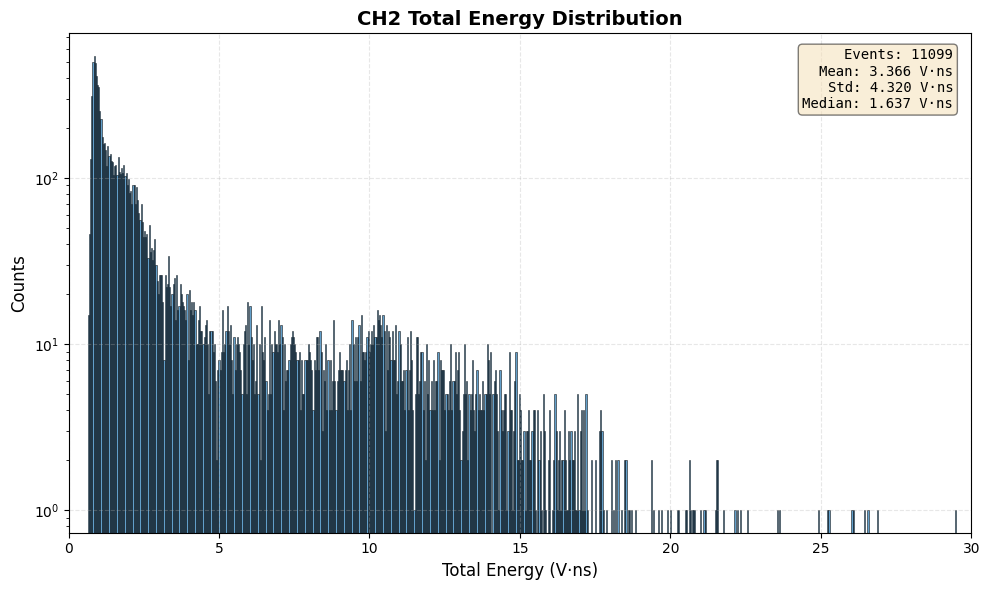

In [46]:
# Plot energy distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram
n, bins, patches = ax.hist(df['energy_V_ns'], bins=5000, alpha=0.7, 
                            edgecolor='black', linewidth=0.5)

ax.set_xlabel('Total Energy (V·ns)', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
# log scale
ax.set_yscale('log')
ax.set_xlim(left=0)  # Ensure x-axis starts at 0
ax.set_xlim(right=30)  # Ensure x-axis starts at 0
ax.set_title('CH2 Total Energy Distribution', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Add statistics text box
stats_text = f"""Events: {len(df)}
Mean: {df['energy_V_ns'].mean():.3f} V·ns
Std: {df['energy_V_ns'].std():.3f} V·ns
Median: {df['energy_V_ns'].median():.3f} V·ns"""
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=10, family='monospace')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ch2_energy_distribution.png", dpi=150, bbox_inches='tight')
print(f"\nPlot saved to: {RESULTS_DIR / 'ch2_energy_distribution.png'}")
plt.show()


Log scale plot saved to: docs/output/ch2_energy_distribution_log.png


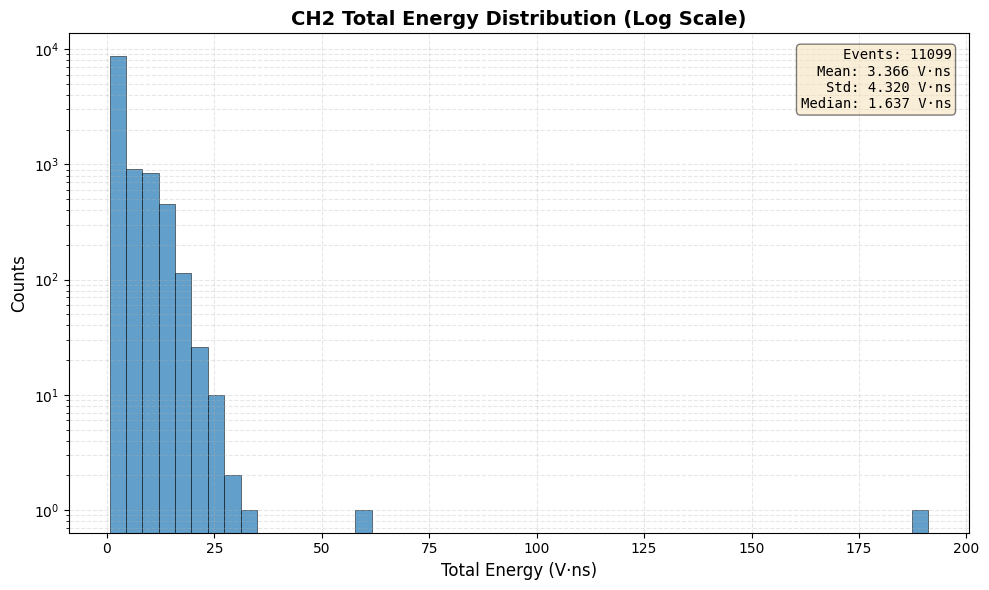

In [47]:
# Plot energy distribution with log scale on y-axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram
n, bins, patches = ax.hist(df['energy_V_ns'], bins=50, alpha=0.7, 
                            edgecolor='black', linewidth=0.5)

ax.set_xlabel('Total Energy (V·ns)', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('CH2 Total Energy Distribution (Log Scale)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, linestyle='--', which='both')

# Add statistics text box
stats_text = f"""Events: {len(df)}
Mean: {df['energy_V_ns'].mean():.3f} V·ns
Std: {df['energy_V_ns'].std():.3f} V·ns
Median: {df['energy_V_ns'].median():.3f} V·ns"""
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=10, family='monospace')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ch2_energy_distribution_log.png", dpi=150, bbox_inches='tight')
print(f"\nLog scale plot saved to: {RESULTS_DIR / 'ch2_energy_distribution_log.png'}")
plt.show()

In [48]:
# Save results to CSV
output_csv = RESULTS_DIR / "ch2_energy_data.csv"
df.to_csv(output_csv, index=False)
print(f"\nData saved to: {output_csv}")
print(f"Total events saved: {len(df)}")


Data saved to: docs/output/ch2_energy_data.csv
Total events saved: 11099



Plotting 5 sample waveforms...
Sample waveforms saved to: docs/output/ch2_sample_waveforms.png


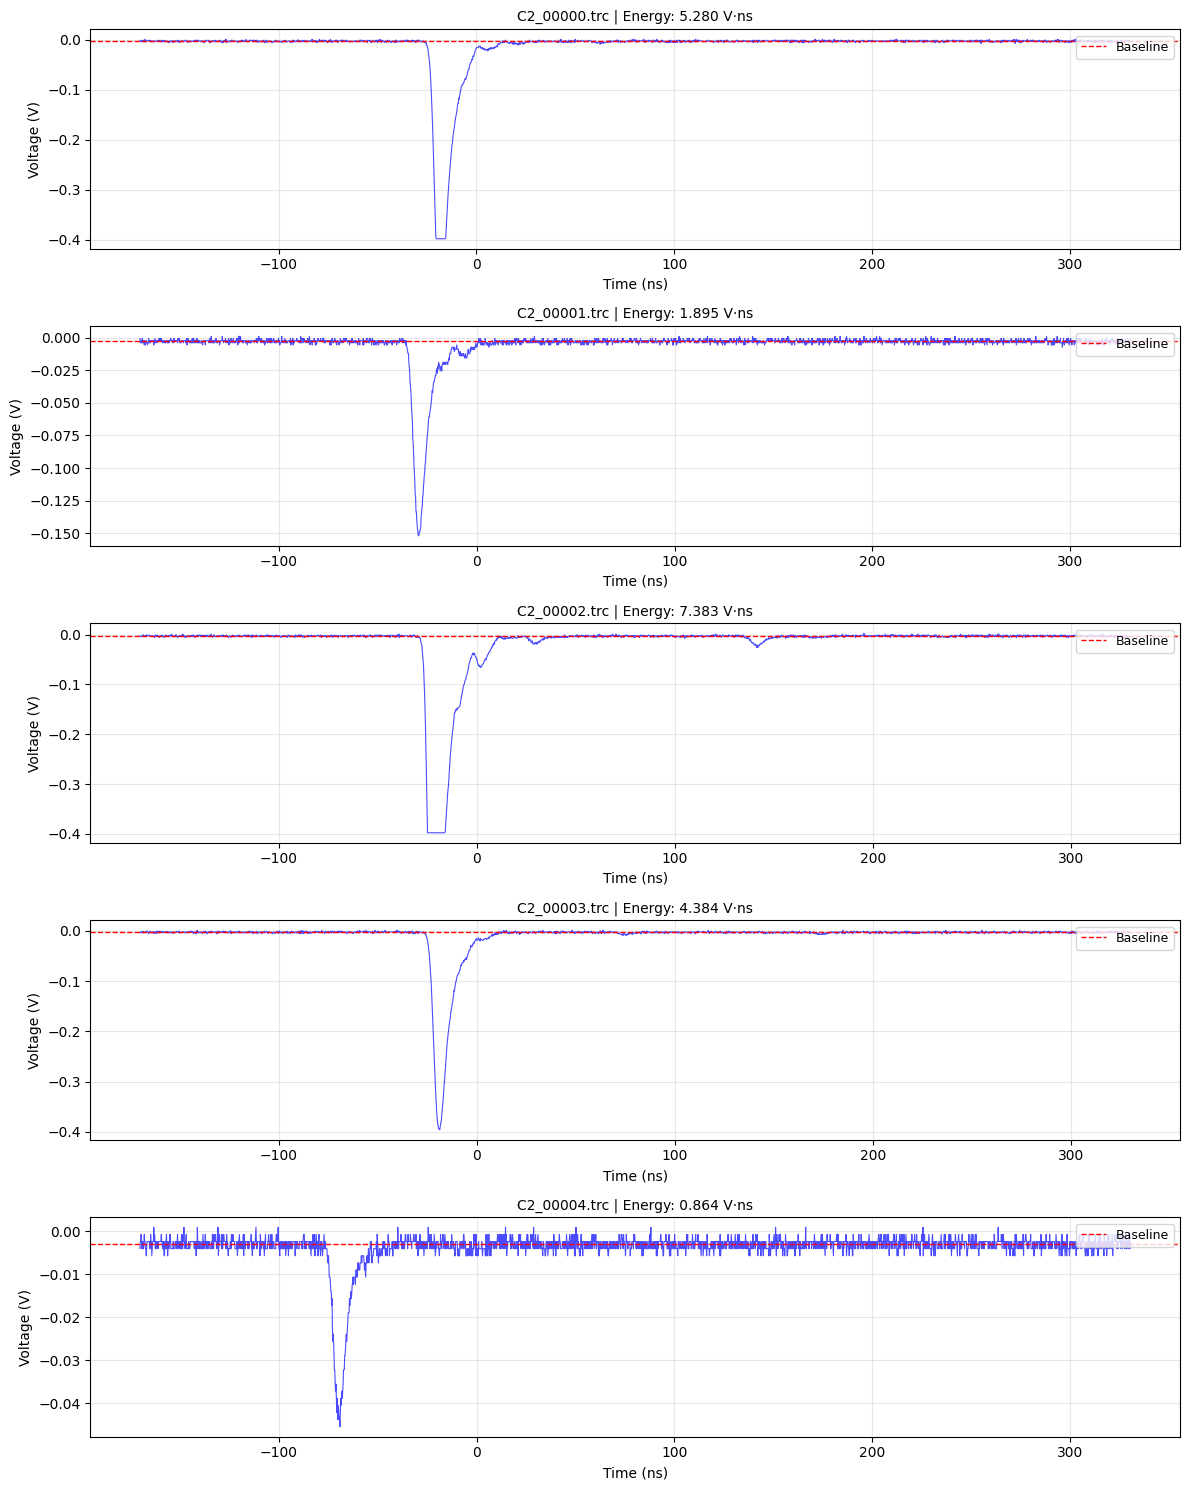

In [49]:
# Plot a few sample waveforms to verify processing
n_samples = min(5, len(ch2_files))
fig, axes = plt.subplots(n_samples, 1, figsize=(12, 3*n_samples))
if n_samples == 1:
    axes = [axes]

print(f"\nPlotting {n_samples} sample waveforms...")
for i in range(n_samples):
    time_ns, voltage_v = load_waveform(ch2_files[i])
    if time_ns is None:
        continue
    
    baseline = np.mean(voltage_v[:10])
    energy = compute_total_energy(time_ns, voltage_v)
    
    axes[i].plot(time_ns, voltage_v, 'b-', linewidth=0.8, alpha=0.7)
    axes[i].axhline(baseline, color='r', linestyle='--', linewidth=1, label='Baseline')
    axes[i].set_xlabel('Time (ns)', fontsize=10)
    axes[i].set_ylabel('Voltage (V)', fontsize=10)
    axes[i].set_title(f"{ch2_files[i].name} | Energy: {energy:.3f} V·ns", fontsize=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ch2_sample_waveforms.png", dpi=150, bbox_inches='tight')
print(f"Sample waveforms saved to: {RESULTS_DIR / 'ch2_sample_waveforms.png'}")
plt.show()

In [50]:
# now ch1
ch1_files = sorted(WAVEFORM_DIR.glob("C1_*.trc"))
print(f"Found {len(ch1_files)} CH1 files")

if max_analyzed_events > 0:
    ch1_files = ch1_files[:max_analyzed_events]
    print(f"Limited to {len(ch1_files)} files for analysis")

if len(ch1_files) == 0:
    raise ValueError(f"No CH1 files found in {WAVEFORM_DIR}")

Found 11099 CH1 files


In [51]:
# Process all CH2 files and compute energies
energies = []
failed_count = 0

print(f"Processing {len(ch1_files)} CH1 files...")
for i, ch1_file in enumerate(ch1_files):
    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{len(ch1_files)} files...")
    
    time_ns, voltage_v = load_waveform(ch1_file)
    
    if time_ns is None or voltage_v is None:
        failed_count += 1
        continue
    
    energy = compute_total_energy(time_ns, voltage_v)
    energies.append({
        'file': ch1_file.name,
        'energy_V_ns': energy
    })

print(f"\nProcessing complete!")
print(f"  Successfully processed: {len(energies)} files")
print(f"  Failed: {failed_count} files")

# Create DataFrame
df = pd.DataFrame(energies)
print(f"\nEnergy statistics:")
print(df['energy_V_ns'].describe())

Processing 11099 CH1 files...
  Processed 100/11099 files...
  Processed 200/11099 files...
  Processed 300/11099 files...
  Processed 400/11099 files...
  Processed 500/11099 files...
  Processed 600/11099 files...
  Processed 700/11099 files...
  Processed 800/11099 files...
  Processed 900/11099 files...
  Processed 1000/11099 files...
  Processed 1100/11099 files...
  Processed 1200/11099 files...
  Processed 1300/11099 files...
  Processed 1400/11099 files...
  Processed 1500/11099 files...
  Processed 1600/11099 files...
  Processed 1700/11099 files...
  Processed 1800/11099 files...
  Processed 1900/11099 files...
  Processed 2000/11099 files...
  Processed 2100/11099 files...
  Processed 2200/11099 files...
  Processed 2300/11099 files...
  Processed 2400/11099 files...
  Processed 2500/11099 files...
  Processed 2600/11099 files...
  Processed 2700/11099 files...
  Processed 2800/11099 files...
  Processed 2900/11099 files...
  Processed 3000/11099 files...
  Processed 3100/11


Log scale plot saved to: docs/output/ch2_energy_distribution_log.png


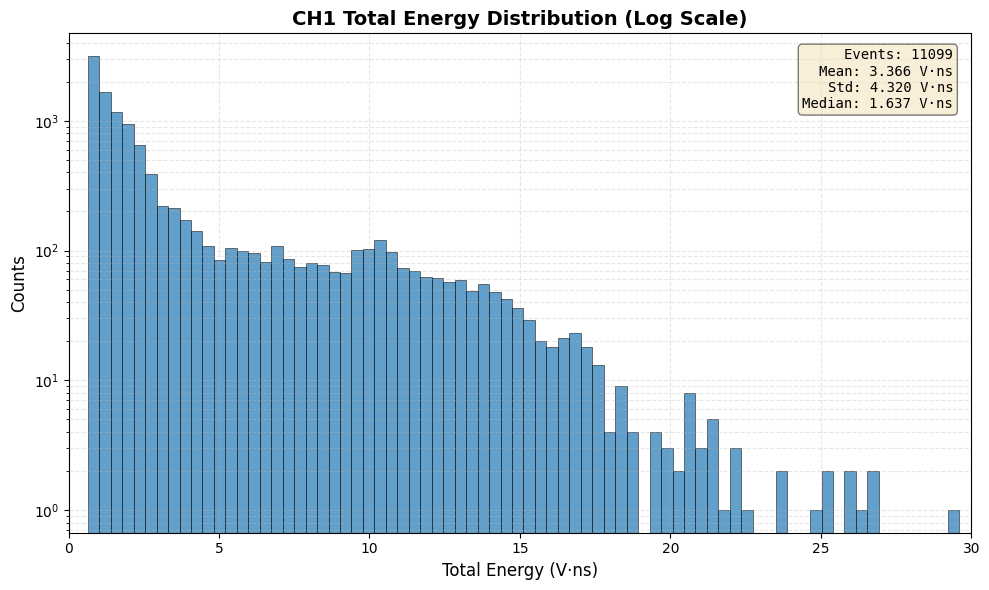

In [52]:
# Plot energy distribution with log scale on y-axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram
n, bins, patches = ax.hist(df['energy_V_ns'], bins=500, alpha=0.7, 
                            edgecolor='black', linewidth=0.5)

ax.set_xlabel('Total Energy (V·ns)', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title('CH2 Total Energy Distribution (Log Scale - 500 bins)', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.set_xlim(left=0)  # Ensure x-axis starts at 0
ax.set_xlim(right=30)  # Ensure x-axis starts at 0
ax.grid(True, alpha=0.3, linestyle='--', which='both')

# Add statistics text box
stats_text = f"""Events: {len(df)}
Mean: {df['energy_V_ns'].mean():.3f} V·ns
Std: {df['energy_V_ns'].std():.3f} V·ns
Median: {df['energy_V_ns'].median():.3f} V·ns"""
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        fontsize=10, family='monospace')

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ch1_energy_distribution_log.png", dpi=150, bbox_inches='tight')
print(f"\nLog scale plot saved to: {RESULTS_DIR / 'ch2_energy_distribution_log.png'}")
plt.show()